# Quickstart: fit a model to data, in a notebook

This is the shortest path from *a model and some data* to *a fitted model and a
plot*, all in one kernel. We will:

1. write a small **edition-2 BNGL** model,
2. generate some noisy synthetic data from it,
3. run a **differential-evolution** fit that recovers the parameters, and
4. plot the fitted model against the data.

Everything runs **in-process**. The command line `pybnf -c fit.conf` starts a Dask
cluster and farms simulations out to worker processes — the right tool for a big
production fit. Inside a notebook we use `pybnf_notebook.run_fit`, a thin helper
that drives PyBNF's *real* algorithm classes to completion synchronously in this
kernel (the same in-process path PyBNF's own test suite uses), so the fitted
objects stay live for the next cell.

In [1]:
import os, tempfile
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl; mpl.rcParams['figure.dpi'] = 80

# BNGL models are simulated by bngsim, which expands the reaction network with
# BioNetGen once. Point BNGPATH at your BioNetGen install (edit if yours differs).
os.environ.setdefault('BNGPATH', os.path.expanduser('~/Simulations/BioNetGen-2.9.3'))

import pybnf_notebook as nb          # the helpers live next to this notebook

WORK = Path(tempfile.mkdtemp(prefix='pybnf_quickstart_'))
print('scratch dir:', WORK)

scratch dir: /var/folders/kt/jm0c72ws5lb9j4wk_c5l3h70000bmg/T/pybnf_quickstart_abxguo10


## 1. A model

A three-species mass-action cascade **A → B → C** with rate constants `k1`, `k2`.
This is an *edition-2* model: there is **no `begin actions` block**. The model
describes only the biology; PyBNF builds the simulation from the data's time grid.
We declare an observable for each species (we will only *measure* A and C).

In [2]:
model_bngl = '''
begin model
  begin parameters
    k1  0.9      # A -> B   [1/min]   (fitted)
    k2  0.35     # B -> C   [1/min]   (fitted)
    A0  100      # initial A          (known)
  end parameters
  begin molecule types
    A()
    B()
    C()
  end molecule types
  begin seed species
    A()  A0
    B()  0
    C()  0
  end seed species
  begin observables
    Molecules  A  A()
    Molecules  B  B()
    Molecules  C  C()
  end observables
  begin reaction rules
    r1: A() -> B()  k1
    r2: B() -> C()  k2
  end reaction rules
end model
'''
model_file = WORK / 'cascade.bngl'
model_file.write_text(model_bngl)
print('wrote', model_file.name)

wrote cascade.bngl


## 2. Some data

We make synthetic data from the model's own closed form (the Bateman equations for
a two-step chain) at a known truth, then add Gaussian measurement noise. Generating
data from the truth is what lets us *check* that the fit recovers it.

$$A(t) = A_0 e^{-k_1 t}, \qquad C(t) = A_0\left[1 - \frac{k_2 e^{-k_1 t} - k_1 e^{-k_2 t}}{k_2 - k_1}\right]$$

In [3]:
k1_true, k2_true, A0 = 0.9, 0.35, 100.0
t = np.linspace(0, 12, 25)
A_true = A0 * np.exp(-k1_true * t)
C_true = A0 * (1 - (k2_true*np.exp(-k1_true*t) - k1_true*np.exp(-k2_true*t)) / (k2_true - k1_true))

rng = np.random.default_rng(0)
A_obs = A_true + rng.normal(0, 2.0, t.size)
C_obs = C_true + rng.normal(0, 2.0, t.size)

# A PyBNF .exp file: a '# time <obs> <obs>' header, then whitespace-separated rows.
# Column names must match model observables (here A and C; B is left unmeasured).
exp_file = WORK / 'cascade.exp'
lines = ['# time\tA\tC']
for ti, ai, ci in zip(t, A_obs, C_obs):
    lines.append(f'{ti:.6g}\t{ai:.6g}\t{ci:.6g}')
exp_file.write_text('\n'.join(lines) + '\n')

nb.load_exp(exp_file).head()

,time,A,C
0,0.0,100.2510,0.188025
1,0.5,63.4986,1.723640
2,1.0,41.9378,8.716570
3,1.5,26.1338,18.781700
4,2.0,15.4586,29.700000


## 3. Configure and run the fit

The `.conf` is the whole recipe: which model, which data, which algorithm, and the
free parameters. `job_type = de` selects **differential evolution**, a robust
gradient-free global optimizer. `run_fit` builds it and runs it here in the kernel.

In [4]:
conf = f'''
edition = 2
model: {model_file}
bngl_backend = bngsim
job_type = de
objective = sos
experiment: cascade, data: {exp_file}
uniform_var = k1  0.05  5
uniform_var = k2  0.05  5
population_size = 16
max_iterations = 30
'''

alg = nb.run_fit(conf, WORK / 'out')
fit = nb.best_fit(alg)

print("          fitted      truth")
print(f"  k1   {fit['k1']:8.4f}   {k1_true}")
print(f"  k2   {fit['k2']:8.4f}   {k2_true}")

Completed 10 of 30 iterations


Completed 20 of 30 iterations


Stop criterion satisfied with objective function value of 80.95485829823527
          fitted      truth
  k1     0.8700   0.9
  k2     0.3619   0.35


## 4. Plot the fit against the data

`simulate` re-runs the model at the fitted parameters. Here we go one better and
draw a **smooth** best-fit curve by handing the fitted rates to bngsim directly on
a fine time grid. Notice that B — which we never measured — is nonetheless
predicted by the fitted model.

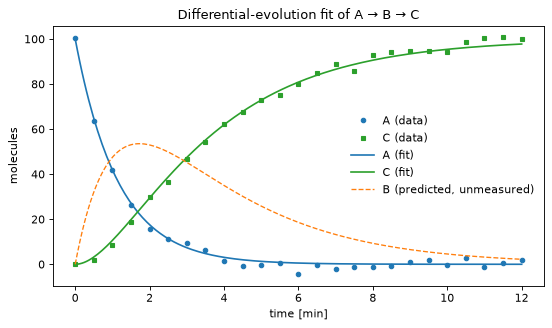

In [5]:
import bngsim

m = bngsim.Model.from_net(nb.net_path(alg))
m.set_param('k1', fit['k1'])
m.set_param('k2', fit['k2'])
curve = bngsim.Simulator(m, method='ode').run((0.0, 12.0), 200).dataframe

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(t, A_obs, 'o', ms=4, color='C0', label='A (data)')
ax.plot(t, C_obs, 's', ms=4, color='C2', label='C (data)')
ax.plot(curve['time'], curve['A'], '-', color='C0', label='A (fit)')
ax.plot(curve['time'], curve['C'], '-', color='C2', label='C (fit)')
ax.plot(curve['time'], curve['B'], '--', color='C1', lw=1.2, label='B (predicted, unmeasured)')
ax.set(xlabel='time [min]', ylabel='molecules', title='Differential-evolution fit of A → B → C')
ax.legend(frameon=False); fig.tight_layout()

## What just happened, and where to go next

- PyBNF wrote its usual artifacts to `alg.res_dir` — the best-fit model, sorted
  parameter tables, and per-iteration output — exactly as the CLI would.
- For a **production** run you would put the same `.conf` on disk and run
  `pybnf -c cascade.conf`; the only thing that changes is the executor (a Dask
  cluster instead of this kernel).

Next:

- **`02_bngsim_simulation.ipynb`** — simulate a model forward with bngsim (no fitting).
- **`03_posterior_exploration.ipynb`** — go Bayesian: sample a posterior and explore it with ArviZ.
- **`04_petab_in_a_notebook.ipynb`** — import a PEtab problem and fit it interactively.

In [6]:
print('Results written to:', alg.res_dir)
print('files:', sorted(p.name for p in Path(alg.res_dir).glob('*')))

Results written to: /var/folders/kt/jm0c72ws5lb9j4wk_c5l3h70000bmg/T/pybnf_quickstart_abxguo10/out/Results
files: ['cascade_bestfit.bngl', 'cascade_gen22ind0.bngl', 'sorted_params_0.txt', 'sorted_params_backup.txt', 'sorted_params_final.txt']
